# 03. Support-localized threshold resolution

This notebook produces the Section 5.2 experiment. It varies the local threshold radius around reserve boundaries and reports the effective boundary sample size, support-adjusted lower bounds, and certification counts. This is the empirical counterpart of the threshold-resolution discussion.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
        CODE_ROOT = candidate
        break
    if (candidate / "code" / "src").is_dir() and (candidate / "code" / "notebooks").is_dir():
        CODE_ROOT = candidate / "code"
        break
else:
    raise RuntimeError("Could not find the project code root.")

sys.path.insert(0, str(CODE_ROOT / "src"))

from IPython.display import Image, display

from config import ExperimentConfig, ProjectPaths
from paper_experiments import (
    build_ipinyou_panels,
    run_appendix_b_diagnostics,
    run_conservative_shortlist,
    run_data_audit,
    run_support_localized_threshold_resolution,
    run_validation_readiness,
)
from progress import ProgressLogger

paths = ProjectPaths.from_repo_root(CODE_ROOT)
paths.ensure()
config = ExperimentConfig(full_run=True)
progress = ProgressLogger(enabled=True)
print(f"Code root: {CODE_ROOT}")
print(f"Data archive: {paths.ipinyou_archive}")
print(f"Artifacts: {paths.artifact_dir}")

Code root: <repo>
Data archive: <repo>/data/archive.zip
Artifacts: <repo>/artifacts


[02:18:30] >> Running Section 5.2 support-localized threshold resolution.
[02:18:30] >> Running Section 5.1 conservative shortlist construction.
[02:18:32]    Using cached replay artifacts for 02_season2.
[02:18:32] OK Section 5.1 artifacts are ready. (2.5s elapsed)
[02:22:23] OK Section 5.2 artifacts are ready. (233.3s elapsed)


,threshold_band_radius,certified_policy_count,max_support_adjusted_lower_bound,median_boundary_sample_size
0,1,2,0.091740,225.0
1,2,3,0.341433,1808.0
2,5,6,0.379460,3482.0
3,10,10,0.407129,6757.0
4,20,11,0.440536,24473.0
5,50,12,0.451895,79966.0
6,100,15,0.468861,509301.0
7,200,18,0.476735,20823622.0


,k,kth_policy_id,next_policy_id,kth_lower_bound_lift,next_lower_bound_lift,shortlist_margin,max_symmetric_perturbation_preserving_topk
0,1,hybrid_q75_if_gap_100,min_positive_floor_q75,0.407129,0.285672,0.121457,0.060729
1,2,min_positive_floor_q75,margin_gap_100_add_20,0.285672,0.088253,0.197419,0.098709
2,3,margin_gap_100_add_20,add_20_all_floors,0.088253,0.087558,0.000695,0.000347
3,5,hybrid_q50_if_gap_50,zero_and_low_floor_to_q50,0.077049,0.077049,0.000000,0.000000
4,10,margin_gap_50_add_10,add_10_all_floors,0.035507,0.034995,0.000512,0.000256


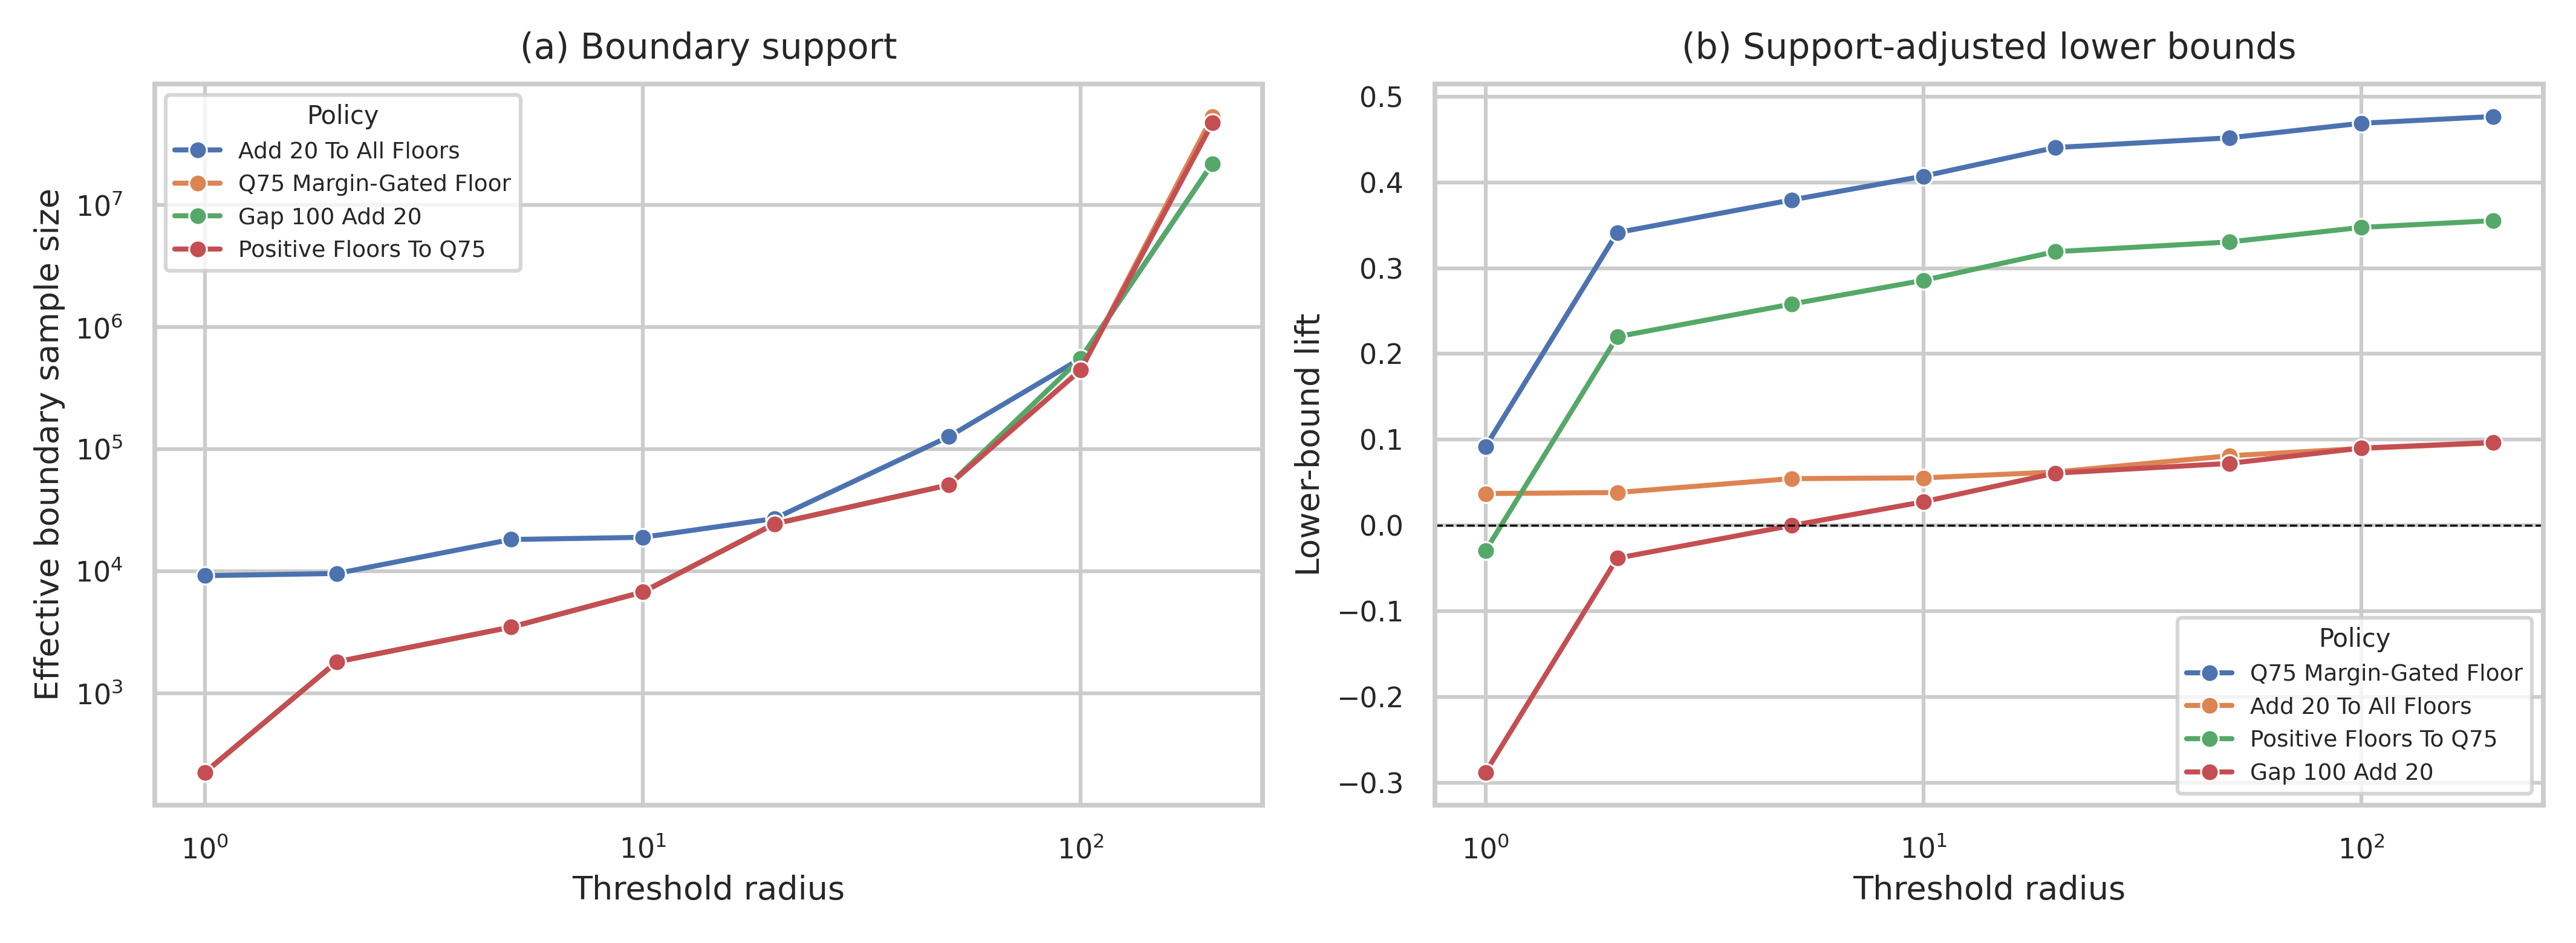

In [2]:
artifacts = run_support_localized_threshold_resolution(paths, config, progress)

display(artifacts["certification_counts"])
display(artifacts["topk_stability"])
display(Image(filename=str(artifacts["figure"])))